<a href="https://colab.research.google.com/github/ayush4628/Movie-Review-Sentiment-Analysis/blob/main/Movie_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Datasets/IMDB_Dataset.csv')

In [ ]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data.shape

(50000, 2)

In [ ]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [ ]:
data.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
# One Hot Encoder
# Label Encoder

In [ ]:
# Positive --> 1
# Negative --> 0

data.replace({'sentiment': {'positive': 1, 'negative': 0}}, inplace=True)

In [ ]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [ ]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0
49999,No one expects the Star Trek movies to be high...,0


In [ ]:
data['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


In [ ]:
data['word_count'] = data['review'].apply(lambda x: len(x.split()))

In [ ]:
data['word_count'].describe()

,word_count
count,50000.000000
mean,231.156940
std,171.343997
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

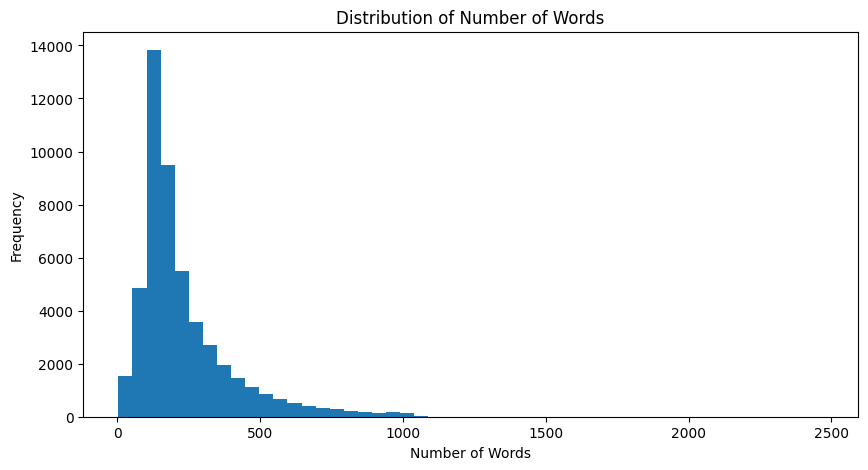

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(data['word_count'], bins=50)

plt.title("Distribution of Number of Words")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

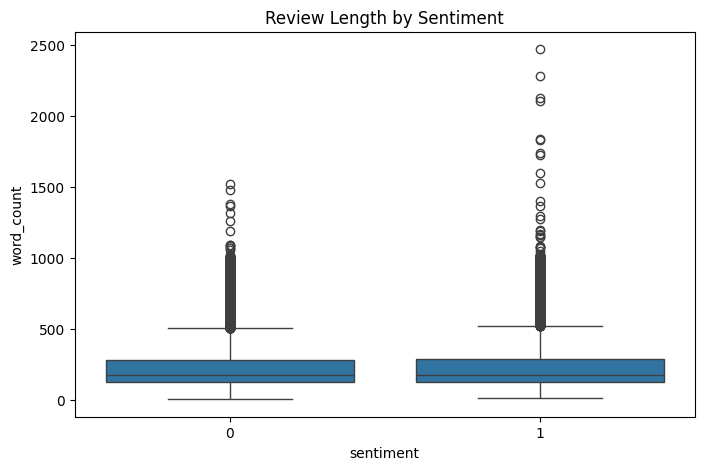

In [ ]:
# Compare review length by sentiment

plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='sentiment',
    y='word_count'
)

plt.title("Review Length by Sentiment")

plt.show()

## **Text-Preprocessing**

In [ ]:
import re
import string

In [ ]:
def clean_text(text):

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
data['clean_review'] = data['review'].apply(clean_text)

In [ ]:
data[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Input, SimpleRNN, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
X = data['clean_review']
y = data['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape

((40000,), (10000,))

In [ ]:
y_train.shape, y_test.shape

((40000,), (10000,))

## **Create Validation set**

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [ ]:
vocab_size = 20000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

In [ ]:
tokenizer.fit_on_texts(X_train)

In [ ]:
word_index = tokenizer.word_index

list(word_index.items())[:20]

[('<OOV>', 1),
 ('the', 2),
 ('a', 3),
 ('and', 4),
 ('of', 5),
 ('to', 6),
 ('is', 7),
 ('in', 8),
 ('it', 9),
 ('i', 10),
 ('this', 11),
 ('that', 12),
 ('was', 13),
 ('as', 14),
 ('with', 15),
 ('for', 16),
 ('movie', 17),
 ('but', 18),
 ('film', 19),
 ('on', 20)]

In [ ]:
#  Convert text into sequences

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_seq[0][:20]

[437,
 434,
 10,
 25,
 6,
 1006,
 15,
 2,
 375,
 35,
 1635,
 11,
 14,
 3330,
 2,
 113,
 8,
 11,
 684,
 563]

In [ ]:
# Find suitable sequence length

train_lengths = X_train.apply(lambda x: len(x.split()))
train_lengths.describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])

,clean_review
count,32000.000000
mean,228.076906
std,168.747323
min,8.000000
50%,171.000000
75%,277.000000
90%,446.000000
95%,583.000000
99%,889.010000
max,2459.000000


In [ ]:
max_length = 600

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)



In [ ]:
X_train_pad.shape

(32000, 600)

## **SimpleRNN**

In [ ]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=128),
    SimpleRNN(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 600, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,217 (9.92 MB)

 Trainable params: 2,601,217 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Model

# history = model.fit(
#     X_train_pad,
#     y_train,
#     validation_data=(X_val_pad, y_val),
#     epochs=10,
#     batch_size=64
# )

In [ ]:
# Early Stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 2,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.5044 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.5027 - loss: 0.6945 - val_accuracy: 0.4952 - val_loss: 0.6933


## **SimpleRNN(Plot training history)**

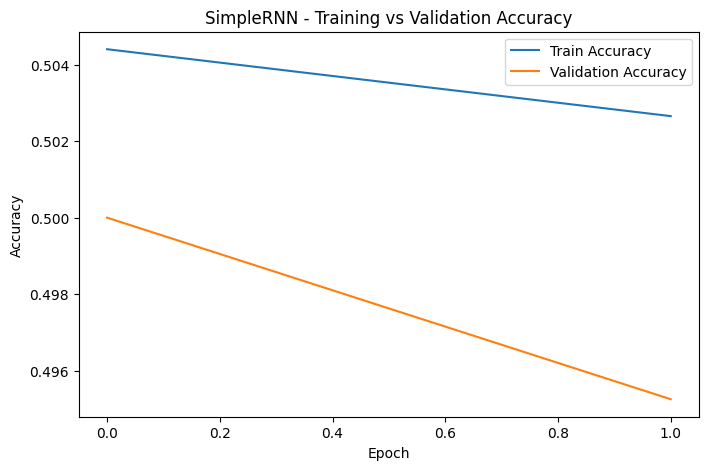

In [ ]:
# Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("SimpleRNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

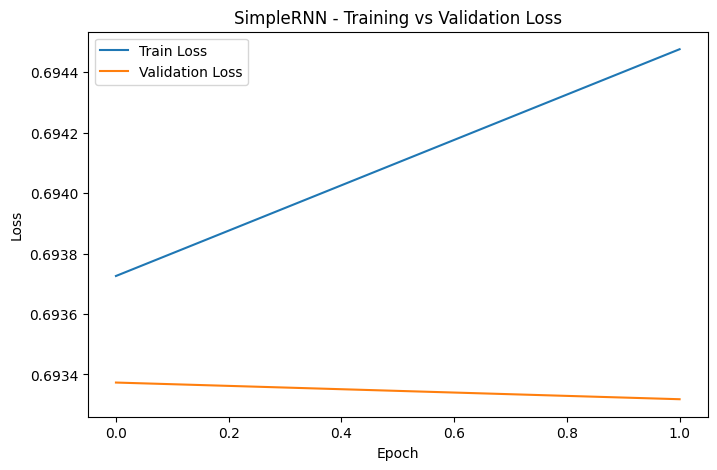

In [ ]:
# Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("SimpleRNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [ ]:
# Evaluate on test data

test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5000 - loss: 0.6930
Test Loss: 0.6930391192436218
Test Accuracy: 0.5


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [ ]:
y_prob = model.predict(X_test_pad)

y_pred = (y_prob >= 0.5).astype(int).ravel()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [ ]:
print(confusion_matrix(y_test, y_pred))

[[   0 5000]
 [   0 5000]]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.5
Precision: 0.5
Recall   : 1.0
F1 Score : 0.6666666666666666


# **LSTM**

In [ ]:
lstm_model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=128, mask_zero=True), # Mask Zero tells Ignore the padding tokens
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [ ]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 600, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train, validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,
    batch_size=64,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.7490 - loss: 0.4968 - val_accuracy: 0.8326 - val_loss: 0.4088
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.8674 - loss: 0.3214 - val_accuracy: 0.8838 - val_loss: 0.2951
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.9330 - loss: 0.1879 - val_accuracy: 0.8735 - val_loss: 0.3256
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9516 - loss: 0.1376 - val_accuracy: 0.8692 - val_loss: 0.4264


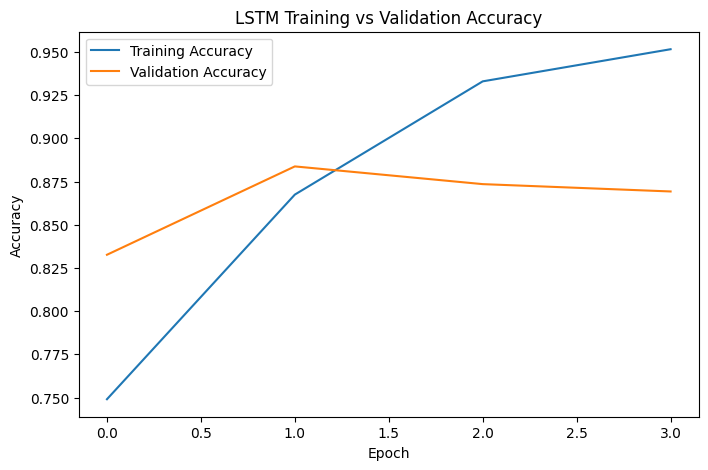

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    lstm_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('LSTM Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

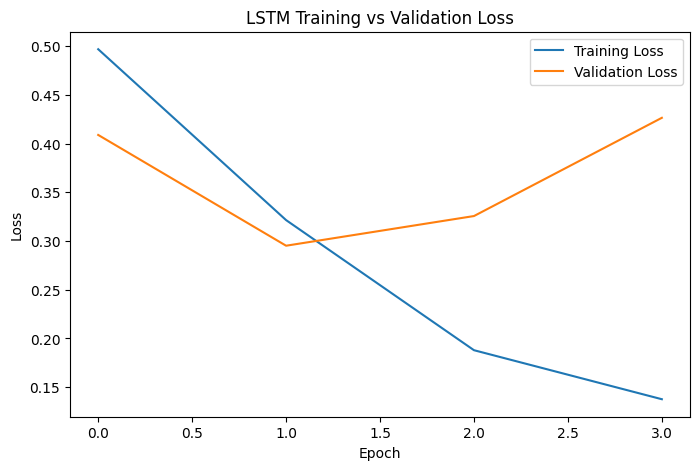

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    lstm_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("LSTM Test Loss:", lstm_loss)
print("LSTM Test Accuracy:", lstm_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8823 - loss: 0.2960
LSTM Test Loss: 0.29599305987358093
LSTM Test Accuracy: 0.8823000192642212


In [ ]:
lstm_prob = lstm_model.predict(X_test_pad)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [ ]:
lstm_pred = (lstm_prob >= 0.5).astype(int).ravel()

In [ ]:
print("confusion_matrix: \n", confusion_matrix(y_test, lstm_pred))

confusion_matrix: 
 [[4233  767]
 [ 410 4590]]


In [ ]:
lstm_accuracy = accuracy_score(y_test, lstm_pred)

lstm_precision = precision_score(y_test, lstm_pred)

lstm_recall = recall_score(y_test, lstm_pred)

lstm_f1 = f1_score(y_test, lstm_pred)

print("LSTM Accuracy :", lstm_accuracy)
print("LSTM Precision:", lstm_precision)
print("LSTM Recall   :", lstm_recall)
print("LSTM F1 Score :", lstm_f1)

LSTM Accuracy : 0.8823
LSTM Precision: 0.8568228486092963
LSTM Recall   : 0.918
LSTM F1 Score : 0.8863570532007338


# **GRU**

In [ ]:
from tensorflow.keras.layers import GRU

In [ ]:
gru_model = Sequential([

    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=128, mask_zero=True),
    GRU(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [ ]:
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 600, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,393 (10.18 MB)

 Trainable params: 2,667,393 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
gru_history = gru_model.fit(
    X_train_pad,
    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,
    batch_size=64,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.7555 - loss: 0.4853 - val_accuracy: 0.8683 - val_loss: 0.3892
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9118 - loss: 0.2354 - val_accuracy: 0.8745 - val_loss: 0.3108


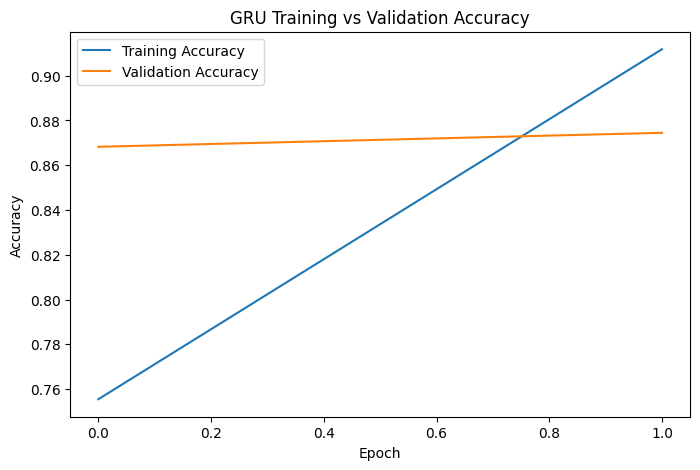

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    gru_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    gru_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('GRU Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

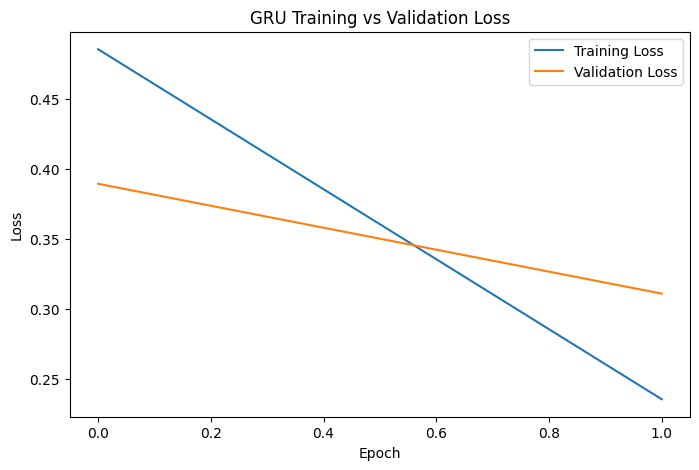

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    gru_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    gru_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('GRU Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
gru_loss, gru_accuracy = gru_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("GRU Test Loss:", gru_loss)
print("GRU Test Accuracy:", gru_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8728 - loss: 0.3721
GRU Test Loss: 0.3721144199371338
GRU Test Accuracy: 0.8727999925613403


In [ ]:
gru_prob = gru_model.predict( X_test_pad)

gru_pred = (gru_prob >= 0.5).astype(int).ravel()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [ ]:
print("confusion_matrix: \n", confusion_matrix(y_test, gru_pred))

confusion_matrix: 
 [[4051  949]
 [ 323 4677]]


In [ ]:
gru_accuracy = accuracy_score(y_test, gru_pred)

gru_precision = precision_score(y_test, gru_pred)

gru_recall = recall_score(y_test, gru_pred)

gru_f1 = f1_score(y_test,gru_pred)

print("GRU Accuracy :", gru_accuracy)
print("GRU Precision:", gru_precision)
print("GRU Recall   :", gru_recall)
print("GRU F1 Score :", gru_f1)

GRU Accuracy : 0.8728
GRU Precision: 0.8313188766441522
GRU Recall   : 0.9354
GRU F1 Score : 0.8802936194240542


## **Now camparidon all model**

In [ ]:
rnn_accuracy = accuracy_score(y_test, y_pred)
rnn_precision = precision_score(y_test, y_pred)
rnn_recall = recall_score(y_test, y_pred)
rnn_f1 = f1_score(y_test, y_pred)

In [ ]:
comparison = pd.DataFrame({'Model': ['SimpleRNN', 'LSTM', 'GRU'],

    'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy],

    'Precision': [rnn_precision ,lstm_precision, gru_precision],

    'Recall': [rnn_recall, lstm_recall, gru_recall],

    'F1 Score': [rnn_f1, lstm_f1, gru_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,SimpleRNN,0.5000,0.500000,1.0000,0.666667
1,LSTM,0.8823,0.856823,0.9180,0.886357
2,GRU,0.8728,0.831319,0.9354,0.880294



**Model Comparison:** SimpleRNN, LSTM, and GRU were evaluated on the IMDB sentiment classification dataset using the same preprocessing and evaluation setup. SimpleRNN performed poorly with an F1 score of 26.30%, indicating difficulty in capturing long-term dependencies in lengthy movie reviews. LSTM significantly improved performance, achieving 88.05% accuracy and an F1 score of 87.90%. GRU achieved the best performance with 90.34% accuracy, 91.64% precision, 88.78% recall, and 90.19% F1 score. Therefore, GRU was selected as the best-performing recurrent architecture for this experiment.

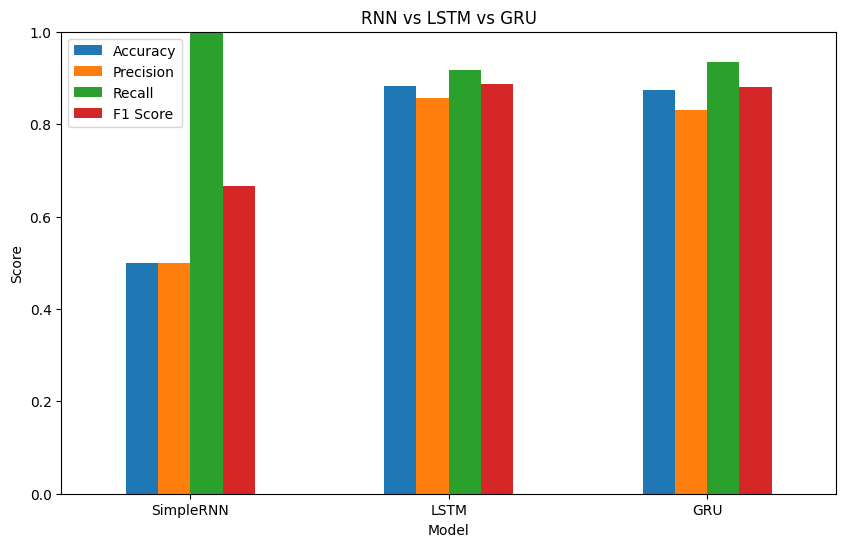

In [ ]:
comparison.set_index(
    'Model'
)[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('RNN vs LSTM vs GRU')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

##**Test Our Model**

In [ ]:
def predict_review(review):

    # 1. Clean the review
    cleaned_review = clean_text(review)

    # 2. Convert text to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_review])

    # 3. Padding
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    # 4. Prediction using GRU
    probability = gru_model.predict(
        padded_sequence,
        verbose=0
    )[0][0]

    # 5. Convert probability to sentiment
    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability
    else:
        sentiment = "Negative"
        confidence = 1 - probability

    print("Review:")
    print(review)
    print()
    print("Predicted Sentiment :", sentiment)
    print("Confidence          :", round(float(confidence) * 100, 2), "%")

In [ ]:
review = """
This movie was absolutely amazing.
The story was fantastic, the acting was brilliant,
and I really enjoyed watching it.
"""

predict_review(review)

Review:

This movie was absolutely amazing. 
The story was fantastic, the acting was brilliant,
and I really enjoyed watching it.


Predicted Sentiment : Positive
Confidence          : 97.95 %


In [ ]:
review = """
The movie started very well and I really enjoyed the first half,
but the second half was extremely boring and disappointing.
"""

predict_review(review)

Review:

The movie started very well and I really enjoyed the first half,
but the second half was extremely boring and disappointing.


Predicted Sentiment : Negative
Confidence          : 88.43 %


#Creating GRU-Lie for deploying purpose(its takes not much space like GRU)

In [ ]:
vocab_size = 20000

tokenizer_lite = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer_lite.fit_on_texts(
    X_train
)

print(
    "Vocabulary size:",
    len(tokenizer_lite.word_index)
)

Vocabulary size: 130052


**Change sequence length from 600 → 300**

 This is one of the biggest deployment optimizations.

In [ ]:
max_length_lite = 300

In [ ]:
X_train_seq_lite = (
    tokenizer_lite.texts_to_sequences(
        X_train
    )
)

X_val_seq_lite = (
    tokenizer_lite.texts_to_sequences(
        X_val
    )
)

X_test_seq_lite = (
    tokenizer_lite.texts_to_sequences(
        X_test
    )
)

In [ ]:
X_train_pad_lite = pad_sequences(
    X_train_seq_lite,
    maxlen=max_length_lite,
    padding='post',
    truncating='post'
)

X_val_pad_lite = pad_sequences(
    X_val_seq_lite,
    maxlen=max_length_lite,
    padding='post',
    truncating='post'
)

X_test_pad_lite = pad_sequences(
    X_test_seq_lite,
    maxlen=max_length_lite,
    padding='post',
    truncating='post'
)

In [ ]:
print(
    "Train shape:",
    X_train_pad_lite.shape
)

print(
    "Validation shape:",
    X_val_pad_lite.shape
)

print(
    "Test shape:",
    X_test_pad_lite.shape
)

Train shape: (32000, 300)
Validation shape: (8000, 300)
Test shape: (10000, 300)


In [ ]:
gru_lite_model = Sequential([

    Input(shape=(max_length_lite,)),

    Embedding(input_dim=vocab_size, output_dim=64,mask_zero=True),

    GRU(64),

    Dropout(0.3),

    Dense(32,activation='relu'),

    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

In [ ]:
gru_lite_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
gru_lite_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 300, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,307,073 (4.99 MB)

 Trainable params: 1,307,073 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_lite = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

**learning-rate reduction**

In [ ]:
from tensorflow.keras.callbacks import (ReduceLROnPlateau)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

In [ ]:
gru_lite_history = gru_lite_model.fit(X_train_pad_lite,y_train,

    validation_data=(
        X_val_pad_lite,
        y_val
    ),

    epochs=8,

    batch_size=64,

    callbacks=[
        early_stopping_lite,
        reduce_lr
    ]
)

Epoch 1/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7864 - loss: 0.4438 - val_accuracy: 0.8665 - val_loss: 0.3283 - learning_rate: 0.0010
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9112 - loss: 0.2374 - val_accuracy: 0.8848 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9461 - loss: 0.1547 - val_accuracy: 0.8914 - val_loss: 0.3201 - learning_rate: 0.0010
Epoch 4/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9762 - loss: 0.0800 - val_accuracy: 0.8924 - val_loss: 0.3769 - learning_rate: 5.0000e-04


In [ ]:
lite_loss, lite_accuracy = (
    gru_lite_model.evaluate(
        X_test_pad_lite,
        y_test,
        verbose=1
    )
)

print("GRU-Lite Test Loss:", lite_loss)

print( "GRU-Lite Test Accuracy:", lite_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8867 - loss: 0.2859
GRU-Lite Test Loss: 0.2859160006046295
GRU-Lite Test Accuracy: 0.8866999745368958


In [ ]:
lite_prob = gru_lite_model.predict(X_test_pad_lite, verbose=1)

lite_pred = (lite_prob >= 0.5).astype(int).ravel()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
lite_accuracy = accuracy_score(y_test, lite_pred)
lite_precision = precision_score(y_test, lite_pred)
lite_recall = recall_score(y_test, lite_pred)
lite_f1 = f1_score(y_test, lite_pred)


print("GRU-Lite Accuracy :", round(lite_accuracy, 4))
print("GRU-Lite Precision:", round(lite_precision, 4))
print("GRU-Lite Recall   :", round(lite_recall, 4))
print("GRU-Lite F1 Score :", round(lite_f1, 4))

GRU-Lite Accuracy : 0.8867
GRU-Lite Precision: 0.8611
GRU-Lite Recall   : 0.9222
GRU-Lite F1 Score : 0.8906


In [ ]:
cm_lite = confusion_matrix(y_test,lite_pred)

print("GRU-Lite Confusion Matrix:\n",cm_lite)

GRU-Lite Confusion Matrix:
 [[4256  744]
 [ 389 4611]]


#**Save the Model**

In [ ]:
gru_lite_model.save("imdb_gru_lite_model.keras")

In [ ]:
import pickle

with open("imdb_tokenizer_lite.pkl", "wb") as file:
    pickle.dump(tokenizer_lite,file)

In [ ]:
import json

config_lite = {

    "max_length": 300,

    "threshold": 0.5,

    "vocab_size": 20000,

    "model": "GRU-Lite",

    "embedding_dim": 64,

    "gru_units": 64
}

with open("config_lite.json", "w") as file:
    json.dump(config_lite,file,indent=4)

In [ ]:
import time

review = """
This movie was absolutely amazing. The story was fantastic,
the acting was brilliant, and I really enjoyed watching it.
"""

cleaned = clean_text(review)

sequence = tokenizer_lite.texts_to_sequences(
    [cleaned]
)

padded = pad_sequences(
    sequence,
    maxlen=300,
    padding="post",
    truncating="post"
)

start = time.time()

prediction = gru_lite_model(
    padded,
    training=False
)

probability = float(
    prediction.numpy()[0][0]
)

elapsed = time.time() - start

print("Prediction:", probability)
print("Positive:", round(probability * 100, 2), "%")
print("Negative:", round((1 - probability) * 100, 2), "%")
print("Time:", round(elapsed, 3), "seconds")

Prediction: 0.9573417901992798
Positive: 95.73 %
Negative: 4.27 %
Time: 0.02 seconds


In [ ]:
review = """
This movie was extremely boring and disappointing.
The story was weak, the acting was terrible, and
I regret wasting my time watching it.
"""

cleaned = clean_text(review)

sequence = tokenizer_lite.texts_to_sequences(
    [cleaned]
)

padded = pad_sequences(
    sequence,
    maxlen=300,
    padding="post",
    truncating="post"
)

start = time.time()

prediction = gru_lite_model(
    padded,
    training=False
)

probability = float(
    prediction.numpy()[0][0]
)

elapsed = time.time() - start

print("Prediction:", probability)
print("Positive:", round(probability * 100, 2), "%")
print("Negative:", round((1 - probability) * 100, 2), "%")
print("Time:", round(elapsed, 3), "seconds")

Prediction: 0.009811364114284515
Positive: 0.98 %
Negative: 99.02 %
Time: 0.02 seconds
